# Probabilistic Water-Demand Forecasting with Quantile Regression

The point-forecasting portion of this project asks:

> **What is our best estimate of tomorrow's municipal water demand?**

That is useful, but it does not describe forecast uncertainty. For planning and
operational decisions, we may also care about lower-demand conditions, unusually
high conditional demand, and how wide the plausible range of demand is under the
information available today.

This notebook extends the existing Fort Collins one-day-ahead workflow from
**point prediction** to **conditional quantile prediction**.

The analysis has five goals:

1. motivate probabilistic water-demand forecasting;
2. explain linear quantile regression as a data-science model;
3. compare linear quantile regression with quantile XGBoost under the same chronological evaluation design;
4. examine what the expanding-window forecasts reveal about uncertainty;
5. identify the remaining gap between estimated conditional quantiles and calibrated predictive uncertainty.

### Domain motivation

Papacharalampous and Langousis (2022), *Probabilistic Water Demand Forecasting
Using Quantile Regression Algorithms*, study quantile-regression-based systems
for one-day-ahead urban water-demand forecasting. Their comparison includes
classical quantile regression, linear boosting, generalized random forests,
gradient boosting machines, and a quantile neural network.

Their study provides a domain-specific reason to treat
quantile regression as a serious framework for probabilistic water-demand
forecasting.

> Papacharalampous, G. & Langousis, A. (2022). *Probabilistic Water Demand
> Forecasting Using Quantile Regression Algorithms*. Water Resources Research,
> 58(6), e2021WR030216.  
> https://doi.org/10.1029/2021WR030216

### Evaluation boundary

The April 2025–March 2026 holdout has already been opened for the completed
point-forecasting analysis. It is therefore **not reused as a new untouched test
set** here.

The primary evidence in this notebook comes from the same nine expanding-window
validation folds spanning January 2023 through March 2025.

## Technical setup

The notebook uses the project's existing feature-building and time-split
utilities rather than re-implementing the forecasting pipeline. This preserves
the same one-day-ahead information boundary used in the point-forecasting work.

The default design matrix is **Matrix B**, the 54-predictor operational feature
set containing demand history, rolling summaries, calendar information,
holidays, and lagged weather.

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

REPOSITORY_NAME = "municipal-water-demand-forecasting"
REPOSITORY_URL = (
    "https://github.com/fureyc/"
    "municipal-water-demand-forecasting.git"
)

def find_repository_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (
            (candidate / "config" / "modeling.yml").exists()
            and (
                candidate / "data" / "processed"
                / "fort_collins_daily_water_weather.csv"
            ).exists()
        ):
            return candidate
    return None

repo_root = find_repository_root()

if repo_root is None:
    clone_parent = Path("/content") if Path("/content").exists() else Path.cwd()
    clone_target = clone_parent / REPOSITORY_NAME
    if not clone_target.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORY_URL, str(clone_target)],
            check=True,
        )
    repo_root = find_repository_root(clone_target)

if repo_root is None:
    raise FileNotFoundError("Could not locate the project repository.")

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)
print("Working directory:", Path.cwd())

Repository root: /content/municipal-water-demand-forecasting
Working directory: /content/municipal-water-demand-forecasting


In [ ]:
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q", "-r",
        str(repo_root / "requirements.txt"),
    ],
    check=True,
)

print("Dependencies are available.")

Dependencies are available.


In [ ]:
from __future__ import annotations

from time import perf_counter
import importlib.metadata as metadata
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.linear_model import QuantileRegressor
from sklearn.metrics import mean_pinball_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from src.evaluation.time_splits import (
    build_expanding_window_splits,
    get_final_holdout,
    load_modeling_config,
)
from src.features.build_forecasting_features import (
    DATE_COLUMN,
    TARGET_COLUMN,
    load_and_build_forecasting_features,
)

RANDOM_STATE = 2026
FEATURE_MATRIX = "B"

QUANTILES = (0.10, 0.50, 0.90)
LOWER_TAU = 0.10
MEDIAN_TAU = 0.50
UPPER_TAU = 0.90

environment_versions = pd.Series(
    {
        "Python": platform.python_version(),
        "NumPy": metadata.version("numpy"),
        "pandas": metadata.version("pandas"),
        "Matplotlib": metadata.version("matplotlib"),
        "scikit-learn": metadata.version("scikit-learn"),
        "XGBoost": metadata.version("xgboost"),
    },
    name="version",
)
display(environment_versions.to_frame())

,version
Python,3.12.13
NumPy,2.0.2
pandas,2.2.2
Matplotlib,3.10.0
scikit-learn,1.6.1
XGBoost,3.3.0


In [ ]:
CONFIG_PATH = repo_root / "config" / "modeling.yml"
DATA_PATH = (
    repo_root / "data" / "processed"
    / "fort_collins_daily_water_weather.csv"
)

config = load_modeling_config(CONFIG_PATH)
feature_set = load_and_build_forecasting_features(DATA_PATH)

dates = pd.to_datetime(feature_set.dates).reset_index(drop=True)
y = feature_set.target.to_numpy(dtype=float)

if FEATURE_MATRIX.upper() == "A":
    X_df = feature_set.matrix_a.copy()
elif FEATURE_MATRIX.upper() == "B":
    X_df = feature_set.matrix_b.copy()
else:
    raise ValueError("FEATURE_MATRIX must be 'A' or 'B'.")

X = X_df.to_numpy(dtype=float)

assert len(dates) == len(y) == len(X_df)
assert dates.is_monotonic_increasing
assert dates.is_unique
assert np.isfinite(X).all()
assert np.isfinite(y).all()

print("Feature matrix:", FEATURE_MATRIX.upper())
print("Aligned date range:", dates.min().date(), "through", dates.max().date())
print("Observations:", len(y))
print("Predictors:", X.shape[1])
print("Target:", TARGET_COLUMN)

Feature matrix: B
Aligned date range: 2020-01-29 through 2026-03-31
Observations: 2254
Predictors: 54
Target: water_demand_mgd


In [ ]:
raw_daily = pd.read_csv(DATA_PATH, parse_dates=[DATE_COLUMN])

raw_splits = build_expanding_window_splits(raw_daily, config)
raw_holdout = get_final_holdout(raw_daily, config)

aligned_splits = []

for split in raw_splits:
    train_mask = dates.between(
        split.train_start,
        split.train_end,
        inclusive="both",
    )
    validation_mask = dates.between(
        split.validation_start,
        split.validation_end,
        inclusive="both",
    )

    train_positions = np.flatnonzero(train_mask.to_numpy())
    validation_positions = np.flatnonzero(validation_mask.to_numpy())

    assert train_positions.size > 0
    assert validation_positions.size > 0
    assert np.intersect1d(train_positions, validation_positions).size == 0
    assert (
        dates.iloc[train_positions].max()
        < dates.iloc[validation_positions].min()
    )

    aligned_splits.append(
        {
            "fold": split.fold,
            "train_start": split.train_start,
            "train_end": split.train_end,
            "validation_start": split.validation_start,
            "validation_end": split.validation_end,
            "train_positions": train_positions,
            "validation_positions": validation_positions,
        }
    )

holdout_mask = dates.between(
    raw_holdout.start,
    raw_holdout.end,
    inclusive="both",
)
aligned_holdout_positions = np.flatnonzero(holdout_mask.to_numpy())

split_summary = pd.DataFrame(
    [
        {
            "fold": split["fold"],
            "train_start": split["train_start"].date(),
            "train_end": split["train_end"].date(),
            "n_train": len(split["train_positions"]),
            "validation_start": split["validation_start"].date(),
            "validation_end": split["validation_end"].date(),
            "n_validation": len(split["validation_positions"]),
        }
        for split in aligned_splits
    ]
)

all_validation_positions = np.concatenate(
    [split["validation_positions"] for split in aligned_splits]
)

assert len(aligned_splits) == 9
assert len(np.unique(all_validation_positions)) == len(all_validation_positions)
assert (
    np.intersect1d(
        all_validation_positions,
        aligned_holdout_positions,
    ).size == 0
)

display(split_summary)

print("Rolling-validation folds:", len(aligned_splits))
print("Rolling-validation predictions:", len(all_validation_positions))
print(
    "Validation period:",
    dates.iloc[all_validation_positions].min().date(),
    "through",
    dates.iloc[all_validation_positions].max().date(),
)
print(
    "Previously opened holdout remains excluded:",
    raw_holdout.start.date(),
    "through",
    raw_holdout.end.date(),
)

,fold,train_start,train_end,n_train,validation_start,validation_end,n_validation
0,1,2020-01-01,2022-12-31,1068,2023-01-01,2023-03-31,90
1,2,2020-01-01,2023-03-31,1158,2023-04-01,2023-06-30,91
2,3,2020-01-01,2023-06-30,1249,2023-07-01,2023-09-30,92
3,4,2020-01-01,2023-09-30,1341,2023-10-01,2023-12-31,92
4,5,2020-01-01,2023-12-31,1433,2024-01-01,2024-03-31,91
5,6,2020-01-01,2024-03-31,1524,2024-04-01,2024-06-30,91
6,7,2020-01-01,2024-06-30,1615,2024-07-01,2024-09-30,92
7,8,2020-01-01,2024-09-30,1707,2024-10-01,2024-12-31,92
8,9,2020-01-01,2024-12-31,1799,2025-01-01,2025-03-31,90


Rolling-validation folds: 9
Rolling-validation predictions: 821
Validation period: 2023-01-01 through 2025-03-31
Previously opened holdout remains excluded: 2025-04-01 through 2026-03-31


# 1. From point forecasts to probabilistic forecasts

The completed point-forecasting analysis ranks models by how accurately they
predict a single value for tomorrow's demand. A probabilistic forecast asks a
different question.

Instead of returning only one estimate, we estimate several locations in the
**conditional distribution of demand** given the information available at
forecast time.

For this first extension we use three quantiles:

| Quantile | Interpretation |
|---|---|
| $\tau=0.10$ | lower conditional demand |
| $\tau=0.50$ | conditional median demand |
| $\tau=0.90$ | upper conditional demand |

The lower and upper forecasts form a natural **central 80% conditional quantile
band**.

That phrase is deliberate. An estimated 10th-to-90th percentile band does not,
by itself, guarantee that 80% of future observations will fall inside it.
Empirical coverage is therefore something we will measure, not assume.

# 2. Linear quantile regression as a data-science model

Ordinary least-squares regression is designed to estimate the conditional mean.
Quantile regression instead targets a user-selected conditional quantile.

At a high level:

```text
predictors available today
          |
          +----> 10th-percentile demand forecast
          |
          +----> median demand forecast
          |
          +----> 90th-percentile demand forecast
```

For a quantile level $\tau$, linear quantile regression chooses coefficients
that minimize the pinball loss:


$$
\widehat{\beta}_{\tau}
=
\arg\min_{\beta}
\sum_{i=1}^{n}
\rho_{\tau}\left(y_i-x_i^\top\beta\right).
$$

The important data-science idea is the asymmetric loss:

- the median balances over- and underprediction;
- a high quantile penalizes underprediction more heavily;
- a low quantile penalizes overprediction more heavily.

This lets the same predictor set describe different parts of the conditional
demand distribution.

### Why compare a linear model with XGBoost?

XGBoost was the strongest model in the completed point-forecasting
comparison. Its quantile objective is therefore a useful nonlinear benchmark.

The question here is not whether linear QR must beat XGBoost. It is:

> **Does the point-forecasting advantage of a flexible tree model translate
> into an equally clear advantage when the target becomes probabilistic?**

To keep the comparison focused, the XGBoost architecture below uses the
configuration selected in the point-forecasting work and changes the objective
to quantile loss. We do not independently retune a separate tree architecture
for each quantile, so this should be read as a focused comparison rather than
an exhaustive quantile-XGBoost tuning study.

In [ ]:
def make_linear_quantile_model(tau: float) -> Pipeline:
    return Pipeline(
        [
            ("scale", StandardScaler()),
            (
                "quantile",
                QuantileRegressor(
                    quantile=tau,
                    alpha=0.0,
                    solver="highs",
                    fit_intercept=True,
                ),
            ),
        ]
    )

POINT_XGB_PARAMS = {
    "n_estimators": 600,
    "max_depth": 3,
    "learning_rate": 0.05,
    "min_child_weight": 5.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

def make_quantile_xgboost_model(tau: float) -> XGBRegressor:
    return XGBRegressor(
        **POINT_XGB_PARAMS,
        objective="reg:quantileerror",
        quantile_alpha=tau,
        tree_method="hist",
    )

MODEL_BUILDERS = {
    "Linear QR": make_linear_quantile_model,
    "Quantile XGBoost": make_quantile_xgboost_model,
}

display(
    pd.DataFrame(
        [
            {
                "model": "Linear QR",
                "role": "Simple conditional-quantile model; domain-motivated benchmark",
            },
            {
                "model": "Quantile XGBoost",
                "role": "Nonlinear comparator based on the strongest point model",
            },
        ]
    )
)

,model,role
0,Linear QR,Simple conditional-quantile model; domain-moti...
1,Quantile XGBoost,Nonlinear comparator based on the strongest po...


# 3. Can a simple linear model compete with quantile XGBoost?

All comparisons remain chronological.

For each of the nine expanding-window folds:

1. fit each model using only dates before the validation quarter;
2. fit separate models at $\tau=.10,.50,.90$;
3. predict the following quarter;
4. record pinball loss and fit time;
5. move forward and repeat with the enlarged training window.

The April 2025–March 2026 holdout is not used.

In [ ]:
prediction_rows = []
fit_rows = []

for split in aligned_splits:
    fold = split["fold"]
    train_idx = split["train_positions"]
    validation_idx = split["validation_positions"]

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_validation = X[validation_idx]
    y_validation = y[validation_idx]
    validation_dates = dates.iloc[validation_idx].reset_index(drop=True)

    print(
        f"Fold {fold}: "
        f"{split['validation_start'].date()} through "
        f"{split['validation_end'].date()}"
    )

    for model_name, builder in MODEL_BUILDERS.items():
        for tau in QUANTILES:
            model = builder(tau)

            start = perf_counter()
            model.fit(X_train, y_train)
            fit_seconds = perf_counter() - start

            prediction = np.asarray(
                model.predict(X_validation),
                dtype=float,
            ).ravel()

            fold_loss = mean_pinball_loss(
                y_validation,
                prediction,
                alpha=tau,
            )

            fit_rows.append(
                {
                    "fold": fold,
                    "model": model_name,
                    "tau": tau,
                    "n_train": len(train_idx),
                    "n_validation": len(validation_idx),
                    "pinball_loss": float(fold_loss),
                    "fit_seconds": float(fit_seconds),
                }
            )

            for date, observed, predicted in zip(
                validation_dates,
                y_validation,
                prediction,
            ):
                prediction_rows.append(
                    {
                        "fold": fold,
                        "date": pd.Timestamp(date),
                        "model": model_name,
                        "tau": tau,
                        "y_true": float(observed),
                        "prediction": float(predicted),
                    }
                )

rolling_fit_results = pd.DataFrame(fit_rows)
rolling_predictions = pd.DataFrame(prediction_rows)

print("Prediction rows:", len(rolling_predictions))
print("Unique validation dates:", rolling_predictions["date"].nunique())

Fold 1: 2023-01-01 through 2023-03-31
Fold 2: 2023-04-01 through 2023-06-30
Fold 3: 2023-07-01 through 2023-09-30
Fold 4: 2023-10-01 through 2023-12-31
Fold 5: 2024-01-01 through 2024-03-31
Fold 6: 2024-04-01 through 2024-06-30
Fold 7: 2024-07-01 through 2024-09-30
Fold 8: 2024-10-01 through 2024-12-31
Fold 9: 2025-01-01 through 2025-03-31
Prediction rows: 4926
Unique validation dates: 821


In [ ]:
pinball_rows = []

for (model_name, tau), group in rolling_predictions.groupby(
    ["model", "tau"],
    sort=False,
):
    loss = mean_pinball_loss(
        group["y_true"],
        group["prediction"],
        alpha=float(tau),
    )
    pinball_rows.append(
        {
            "model": model_name,
            "tau": float(tau),
            "pooled_pinball_loss": float(loss),
        }
    )

pinball_summary = pd.DataFrame(pinball_rows)

average_pinball = (
    pinball_summary
    .groupby("model", as_index=False)
    .agg(
        average_across_quantiles=(
            "pooled_pinball_loss",
            "mean",
        )
    )
)

pinball_wide = (
    pinball_summary
    .pivot(
        index="model",
        columns="tau",
        values="pooled_pinball_loss",
    )
    .rename(
        columns={
            0.10: "pinball_q10",
            0.50: "pinball_q50",
            0.90: "pinball_q90",
        }
    )
    .reset_index()
    .merge(average_pinball, on="model", how="left")
)

display(pinball_wide.round(5))

,model,pinball_q10,pinball_q50,pinball_q90,average_across_quantiles
0,Linear QR,0.25093,0.45588,0.19641,0.30107
1,Quantile XGBoost,0.23444,0.42167,0.23260,0.29624


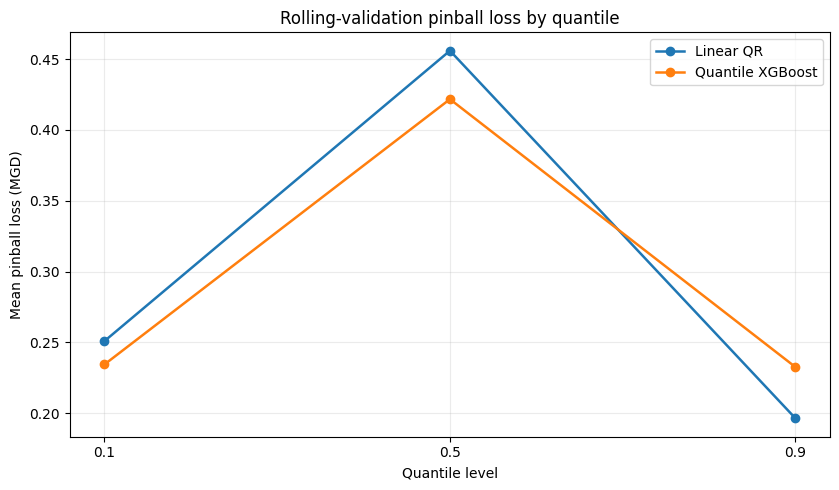

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5))

for model_name, model_df in pinball_summary.groupby("model"):
    model_df = model_df.sort_values("tau")
    ax.plot(
        model_df["tau"],
        model_df["pooled_pinball_loss"],
        marker="o",
        linewidth=1.8,
        label=model_name,
    )

ax.set_title("Rolling-validation pinball loss by quantile")
ax.set_xlabel("Quantile level")
ax.set_ylabel("Mean pinball loss (MGD)")
ax.set_xticks(QUANTILES)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

### What changes when the target becomes probabilistic?

The point-forecasting advantage of XGBoost does not translate into a uniform
advantage across the conditional demand distribution.

Across the rolling validation forecasts, Quantile XGBoost has lower pinball
loss at the 10th percentile and the median. Linear QR, however, performs
substantially better at the 90th percentile:

| Quantile | Linear QR | Quantile XGBoost |
|---|---:|---:|
| 0.10 | 0.2509 | **0.2344** |
| 0.50 | 0.4559 | **0.4217** |
| 0.90 | **0.1964** | 0.2326 |

Averaged across the three quantiles, XGBoost's advantage is small
(0.2962 versus 0.3011 in mean pinball loss).

This makes Linear QR useful for more than its simplicity. In particular, its
stronger upper-tail performance is relevant when the forecasting question
concerns unusually high conditional water demand.

Predictive loss, however, does not tell us whether a nominal quantile behaves
like the stated probability level. We therefore examine calibration and the
resulting central quantile bands next.

In [ ]:
fit_time_summary = (
    rolling_fit_results
    .groupby(["model", "tau"], as_index=False)
    .agg(
        mean_fit_seconds=("fit_seconds", "mean"),
        median_fit_seconds=("fit_seconds", "median"),
        total_fit_seconds=("fit_seconds", "sum"),
    )
)

display(fit_time_summary.round(4))

,model,tau,mean_fit_seconds,median_fit_seconds,total_fit_seconds
0,Linear QR,0.1,0.7205,0.6580,6.4842
1,Linear QR,0.5,0.7930,0.7125,7.1369
2,Linear QR,0.9,0.6813,0.6442,6.1315
3,Quantile XGBoost,0.1,0.7019,0.6940,6.3167
4,Quantile XGBoost,0.5,0.9426,0.7335,8.4831
5,Quantile XGBoost,0.9,0.8981,0.7162,8.0833


# 4. What do the expanding-window forecasts tell us about uncertainty?

For each model, the 10th- and 90th-percentile forecasts define a central
conditional quantile band.

We examine:

- **coverage:** fraction of observations between the estimated 10th and 90th percentiles;
- **average width:** mean distance between the upper and lower forecasts;
- **lower misses:** observations below the estimated 10th percentile;
- **upper misses:** observations above the estimated 90th percentile;
- **quantile crossing:** lower forecast greater than upper forecast.

The nominal central mass is 80%, but 80% coverage is not imposed by the
model. A difference between nominal and empirical coverage is an empirical
finding rather than a software error.

In [ ]:
def interval_metrics_from_wide(frame: pd.DataFrame) -> dict:
    y_true = frame["y_true"].to_numpy(dtype=float)
    lower = frame["q10"].to_numpy(dtype=float)
    upper = frame["q90"].to_numpy(dtype=float)

    return {
        "coverage_80": float(
            np.mean((y_true >= lower) & (y_true <= upper))
        ),
        "average_width": float(np.mean(upper - lower)),
        "lower_miss_rate": float(np.mean(y_true < lower)),
        "upper_miss_rate": float(np.mean(y_true > upper)),
        "crossing_rate": float(np.mean(lower > upper)),
    }

def make_wide_predictions(
    predictions: pd.DataFrame,
    model_name: str,
) -> pd.DataFrame:
    return (
        predictions.loc[
            predictions["model"] == model_name
        ]
        .pivot(
            index=["fold", "date", "y_true"],
            columns="tau",
            values="prediction",
        )
        .reset_index()
        .rename(
            columns={
                LOWER_TAU: "q10",
                MEDIAN_TAU: "q50",
                UPPER_TAU: "q90",
            }
        )
        .sort_values("date")
        .reset_index(drop=True)
    )

wide_predictions = {
    model_name: make_wide_predictions(
        rolling_predictions,
        model_name,
    )
    for model_name in MODEL_BUILDERS
}

pooled_interval_rows = []

for model_name, wide in wide_predictions.items():
    pooled_interval_rows.append(
        {
            "model": model_name,
            **interval_metrics_from_wide(wide),
        }
    )

pooled_interval_summary = pd.DataFrame(pooled_interval_rows)
display(pooled_interval_summary.round(4))

,model,coverage_80,average_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,Linear QR,0.7442,2.5798,0.1389,0.1169,0.0
1,Quantile XGBoost,0.6772,2.4348,0.1998,0.1230,0.0


### Predictive accuracy and uncertainty calibration tell different stories

The difference between the models becomes larger when we examine the full
10th-to-90th percentile band.

Linear QR covers **74.4%** of the rolling-validation observations with an
average width of **2.58 MGD**. Quantile XGBoost covers only **67.7%**, despite
having a somewhat narrower average band of **2.43 MGD**.

Neither reaches the nominal central mass of 80%, so neither raw quantile band
should be interpreted as a calibrated 80% prediction interval.

The miss rates also suggest that the calibration error is not perfectly
symmetric. Linear QR places 13.9% of observations below its estimated 10th
percentile and 11.7% above its estimated 90th percentile. For XGBoost, nearly
20.0% fall below the estimated 10th percentile.

This distinction is important: a model can achieve good pinball loss while its
predicted quantiles still fail to occur at their nominal frequencies. The next
diagnostic examines that property directly at all three fitted quantiles.

In [ ]:
calibration_rows = []

for model_name in MODEL_BUILDERS:
    for tau in QUANTILES:
        model_tau = rolling_predictions.loc[
            (rolling_predictions["model"] == model_name)
            & (rolling_predictions["tau"] == tau)
        ]

        empirical_nonexceedance = np.mean(
            model_tau["y_true"].to_numpy()
            <= model_tau["prediction"].to_numpy()
        )

        calibration_rows.append(
            {
                "model": model_name,
                "tau": tau,
                "nominal_nonexceedance": tau,
                "empirical_nonexceedance": (
                    empirical_nonexceedance
                ),
                "calibration_error": (
                    empirical_nonexceedance - tau
                ),
                "absolute_calibration_error": abs(
                    empirical_nonexceedance - tau
                ),
            }
        )

quantile_calibration = pd.DataFrame(
    calibration_rows
)

display(
    quantile_calibration.round(4)
)

,model,tau,nominal_nonexceedance,empirical_nonexceedance,calibration_error,absolute_calibration_error
0,Linear QR,0.1,0.1,0.1389,0.0389,0.0389
1,Linear QR,0.5,0.5,0.5298,0.0298,0.0298
2,Linear QR,0.9,0.9,0.8831,-0.0169,0.0169
3,Quantile XGBoost,0.1,0.1,0.1998,0.0998,0.0998
4,Quantile XGBoost,0.5,0.5,0.5591,0.0591,0.0591
5,Quantile XGBoost,0.9,0.9,0.8770,-0.0230,0.0230


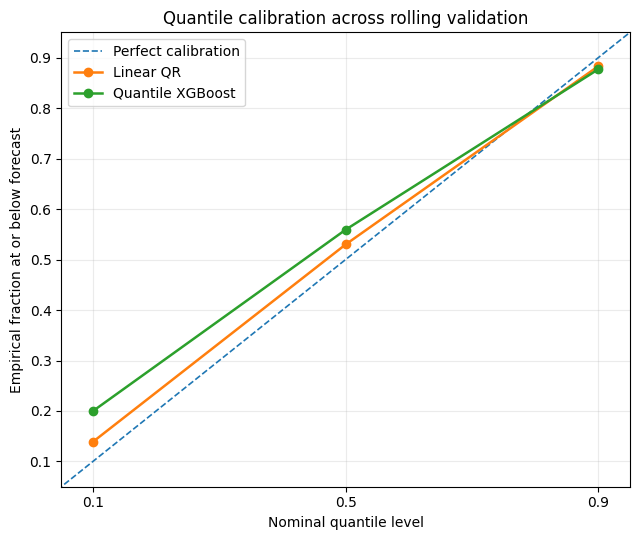

In [ ]:
fig, ax = plt.subplots(
    figsize=(6.5, 5.5),
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Perfect calibration",
)

for (
    model_name,
    model_df,
) in quantile_calibration.groupby("model"):
    model_df = model_df.sort_values("tau")

    ax.plot(
        model_df["nominal_nonexceedance"],
        model_df["empirical_nonexceedance"],
        marker="o",
        linewidth=1.8,
        label=model_name,
    )

ax.set_title(
    "Quantile calibration across rolling validation"
)
ax.set_xlabel("Nominal quantile level")
ax.set_ylabel(
    "Empirical fraction at or below forecast"
)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0.05, 0.95)
ax.set_xticks(QUANTILES)
ax.set_yticks(
    np.arange(0.1, 1.0, 0.1)
)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

### Linear QR is better calibrated despite a small loss disadvantage

The calibration diagnostic adds an important qualification to the pinball-loss
comparison.

For Linear QR, the empirical fractions of observations falling at or below the
estimated 10th, 50th, and 90th percentiles are approximately **13.9%**,
**53.0%**, and **88.3%**, respectively. None is perfectly calibrated, but all
three remain reasonably close to their nominal probability levels.

Quantile XGBoost deviates more strongly, particularly in the lower tail. About
**20.0%** of validation observations fall below its estimated 10th percentile,
even though that forecast is intended to represent a 10% nonexceedance level.
Its median also behaves more like a 56th percentile than a 50th percentile.

This illustrates why probabilistic forecasts should not be evaluated using
pinball loss alone. XGBoost achieves lower loss at the 10th percentile and the
median, but Linear QR produces quantiles whose empirical frequencies are
closer to their stated probability levels.

Both models nevertheless show the same general direction of miscalibration:
the lower quantile tends to be too high, while the upper quantile tends to be
slightly too low. This helps explain why the resulting central bands
under-cover relative to their nominal 80% central mass.

In [ ]:
fold_interval_rows = []

for model_name, wide in wide_predictions.items():
    for fold, fold_df in wide.groupby("fold"):
        fold_interval_rows.append(
            {
                "model": model_name,
                "fold": int(fold),
                "validation_start": fold_df["date"].min(),
                "validation_end": fold_df["date"].max(),
                **interval_metrics_from_wide(fold_df),
            }
        )

fold_interval_results = pd.DataFrame(fold_interval_rows)
display(fold_interval_results.round(4))

,model,fold,validation_start,validation_end,coverage_80,average_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,Linear QR,1,2023-01-01,2023-03-31,0.6889,1.4717,0.1667,0.1444,0.0
1,Linear QR,2,2023-04-01,2023-06-30,0.6923,3.0236,0.2637,0.0440,0.0
2,Linear QR,3,2023-07-01,2023-09-30,0.7717,4.0196,0.1522,0.0761,0.0
3,Linear QR,4,2023-10-01,2023-12-31,0.7283,1.5830,0.1304,0.1413,0.0
4,Linear QR,5,2024-01-01,2024-03-31,0.7363,1.6521,0.1209,0.1429,0.0
5,Linear QR,6,2024-04-01,2024-06-30,0.8132,3.7819,0.0769,0.1099,0.0
6,Linear QR,7,2024-07-01,2024-09-30,0.7609,3.9219,0.1196,0.1196,0.0
7,Linear QR,8,2024-10-01,2024-12-31,0.6957,1.9087,0.1413,0.1630,0.0
8,Linear QR,9,2025-01-01,2025-03-31,0.8111,1.8228,0.0778,0.1111,0.0
9,Quantile XGBoost,1,2023-01-01,2023-03-31,0.8000,1.1032,0.1444,0.0556,0.0


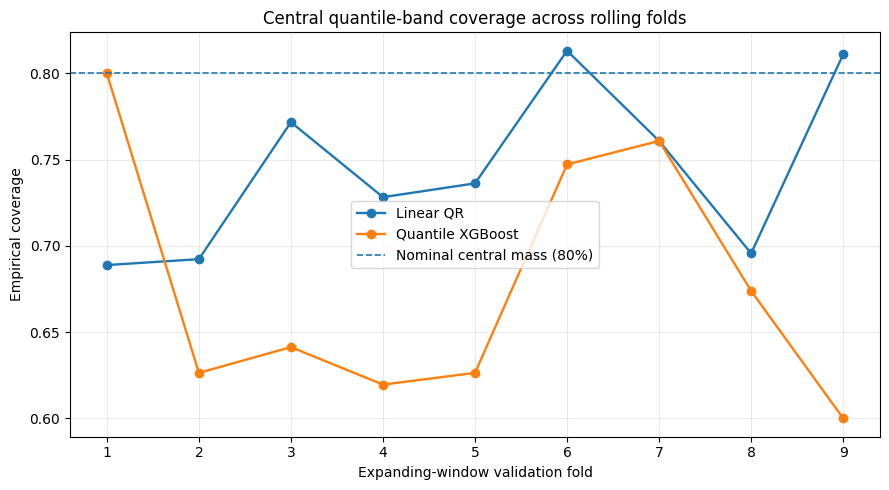

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_name, model_df in fold_interval_results.groupby("model"):
    model_df = model_df.sort_values("fold")
    ax.plot(
        model_df["fold"],
        model_df["coverage_80"],
        marker="o",
        linewidth=1.7,
        label=model_name,
    )

ax.axhline(
    0.80,
    linestyle="--",
    linewidth=1.2,
    label="Nominal central mass (80%)",
)

ax.set_title("Central quantile-band coverage across rolling folds")
ax.set_xlabel("Expanding-window validation fold")
ax.set_ylabel("Empirical coverage")
ax.set_xticks(range(1, 10))
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

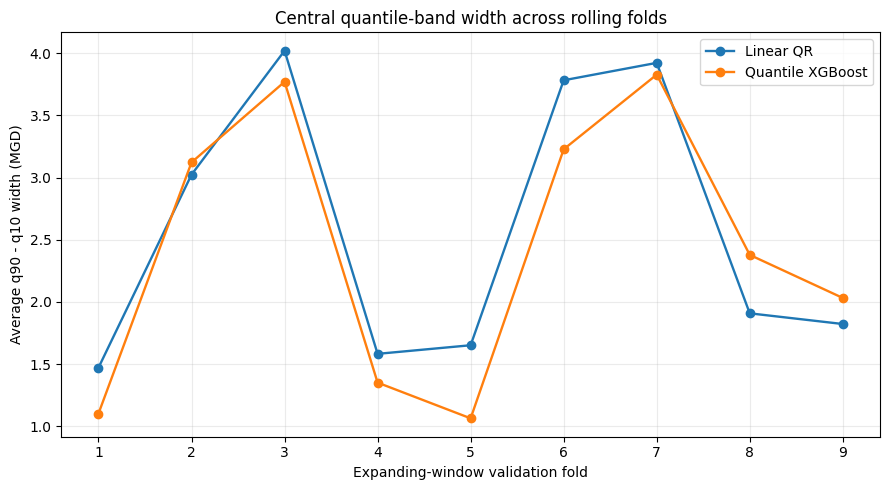

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for model_name, model_df in fold_interval_results.groupby("model"):
    model_df = model_df.sort_values("fold")
    ax.plot(
        model_df["fold"],
        model_df["average_width"],
        marker="o",
        linewidth=1.7,
        label=model_name,
    )

ax.set_title("Central quantile-band width across rolling folds")
ax.set_xlabel("Expanding-window validation fold")
ax.set_ylabel("Average q90 - q10 width (MGD)")
ax.set_xticks(range(1, 10))
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

### Coverage changes over time — and width alone does not explain it

The rolling folds show that calibration is not constant through time.

Linear QR attains higher coverage than Quantile XGBoost in seven of the nine
validation folds, ties it in one, and trails it only in the first fold.
Nevertheless, Linear QR itself ranges from roughly **69% to 81%** coverage,
so its nominal 80% band is not uniformly calibrated.

The width plot provides an important complementary result. Both models widen
their conditional bands substantially during the higher-demand portions of
the year, particularly the third, sixth, and seventh validation folds. The
estimated uncertainty therefore responds to changes in the demand regime
rather than behaving like a fixed-width envelope.

But wider bands do not automatically solve the calibration problem. Some of
the widest folds still under-cover. This suggests that the models are learning
meaningful changes in conditional variability while still imperfectly locating
the tails of the distribution.

## A closer look at the linear-QR forecasts

The model comparison tells us whether linear QR is competitive. The next
question is what its forecasts actually look like over time.

The figure below pools the nine out-of-fold validation quarters. Every plotted
forecast was generated by a model trained only on earlier dates.

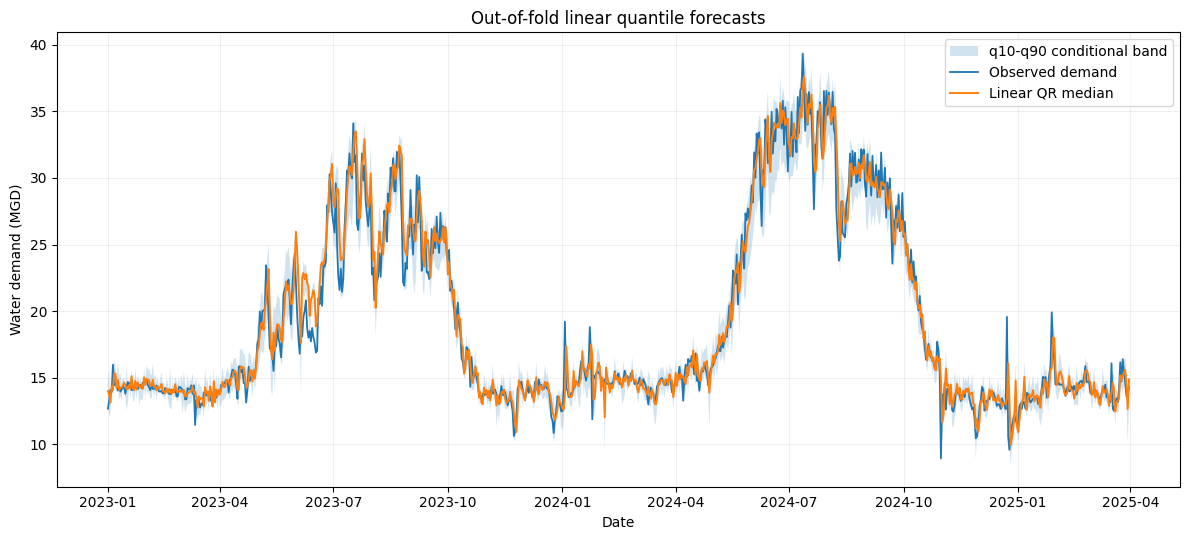

In [ ]:
linear_wide = wide_predictions["Linear QR"].copy()

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.fill_between(
    linear_wide["date"],
    linear_wide["q10"],
    linear_wide["q90"],
    alpha=0.20,
    label="q10-q90 conditional band",
)
ax.plot(
    linear_wide["date"],
    linear_wide["y_true"],
    linewidth=1.3,
    label="Observed demand",
)
ax.plot(
    linear_wide["date"],
    linear_wide["q50"],
    linewidth=1.4,
    label="Linear QR median",
)

ax.set_title("Out-of-fold linear quantile forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Water demand (MGD)")
ax.grid(alpha=0.20)
ax.legend()

fig.tight_layout()
plt.show()

### The quantile band contains information that a point forecast cannot show

The pooled out-of-fold forecasts make the seasonal behavior of uncertainty
visible.

The median forecast closely follows the broad seasonal movement in demand,
while the distance between the 10th and 90th percentiles expands markedly
during the high-demand summer periods and contracts during the cooler,
lower-demand portions of the year.

This is useful even before calibration: the model is not simply placing a
constant margin around the median forecast. It is estimating substantially
greater conditional uncertainty during the most variable demand periods.

At the same time, several sharp movements in observed demand extend outside
the estimated band. The seasonal and fold-level diagnostics below help
determine whether these misses are random or systematically associated with
particular demand regimes.

### Does uncertainty behavior change by season?

The point-forecasting analysis found meaningful seasonal differences in
forecast difficulty. We therefore summarize the linear-QR band by season as a
simple diagnostic of whether coverage or width changes across the year.

This remains a **predictive** analysis. Seasonal differences should not be
interpreted causally.

In [ ]:
def season_from_month(month):
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Fall"

linear_wide["season"] = (
    linear_wide["date"]
    .dt.month
    .map(season_from_month)
)

season_order = ["Winter", "Spring", "Summer", "Fall"]
season_rows = []

for season in season_order:
    season_df = linear_wide.loc[
        linear_wide["season"] == season
    ]

    season_rows.append(
        {
            "season": season,
            "n_observations": len(season_df),
            "median_pinball_loss": float(
                mean_pinball_loss(
                    season_df["y_true"],
                    season_df["q50"],
                    alpha=0.50,
                )
            ),
            **interval_metrics_from_wide(season_df),
        }
    )

linear_season_summary = pd.DataFrame(season_rows)
display(linear_season_summary.round(4))

,season,n_observations,median_pinball_loss,coverage_80,average_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,Winter,240,0.3072,0.7125,1.6143,0.1375,0.1500,0.0
1,Spring,215,0.3434,0.8233,2.4917,0.0837,0.0930,0.0
2,Summer,184,0.8247,0.7120,4.1137,0.2174,0.0707,0.0
3,Fall,182,0.4120,0.7253,2.4062,0.1264,0.1484,0.0


### Summer demand is both more uncertain and harder to locate

The seasonal results reinforce what is visible in the out-of-fold forecast.

Linear QR produces its widest conditional band in summer, averaging about
**4.11 MGD**, compared with only **1.61 MGD** in winter. The model therefore
recognizes that summer demand is considerably more variable.

Yet summer coverage is only **71.2%**, despite the wider band, and median
pinball loss rises to **0.825 MGD**. In contrast, spring coverage is about
**82.3%**, close to the nominal 80% central mass.

The direction of the summer misses is also asymmetric: about **21.7%** of
summer observations fall below the estimated 10th percentile, while only
**7.1%** exceed the estimated 90th percentile.

This suggests that the challenge is not simply that summer demand has greater
variance. During some summer periods, the fitted conditional distribution
appears shifted too high relative to realized demand.

This is a predictive diagnostic rather than a causal conclusion. Weather,
irrigation behavior, conservation responses, or other unmodeled processes
could contribute to the pattern, but these results alone do not identify the
cause.

### Are misses concentrated on one side?

For a well-behaved 10th-to-90th percentile band, misses should occur on both
sides rather than being almost entirely concentrated above or below the band.

The table below makes that asymmetry visible fold by fold for linear QR.

In [ ]:
linear_fold_diagnostics = (
    fold_interval_results.loc[
        fold_interval_results["model"] == "Linear QR"
    ]
    [
        [
            "fold",
            "validation_start",
            "validation_end",
            "coverage_80",
            "average_width",
            "lower_miss_rate",
            "upper_miss_rate",
            "crossing_rate",
        ]
    ]
    .reset_index(drop=True)
)

display(linear_fold_diagnostics.round(4))

,fold,validation_start,validation_end,coverage_80,average_width,lower_miss_rate,upper_miss_rate,crossing_rate
0,1,2023-01-01,2023-03-31,0.6889,1.4717,0.1667,0.1444,0.0
1,2,2023-04-01,2023-06-30,0.6923,3.0236,0.2637,0.0440,0.0
2,3,2023-07-01,2023-09-30,0.7717,4.0196,0.1522,0.0761,0.0
3,4,2023-10-01,2023-12-31,0.7283,1.5830,0.1304,0.1413,0.0
4,5,2024-01-01,2024-03-31,0.7363,1.6521,0.1209,0.1429,0.0
5,6,2024-04-01,2024-06-30,0.8132,3.7819,0.0769,0.1099,0.0
6,7,2024-07-01,2024-09-30,0.7609,3.9219,0.1196,0.1196,0.0
7,8,2024-10-01,2024-12-31,0.6957,1.9087,0.1413,0.1630,0.0
8,9,2025-01-01,2025-03-31,0.8111,1.8228,0.0778,0.1111,0.0


### Miscalibration is not purely a fixed-width problem

The direction of the misses also changes from one validation period to
another.

For example, Fold 2 is dominated by observations falling below the estimated
lower quantile, whereas later folds are considerably more balanced. A single
global widening of every interval would therefore not necessarily address the
underlying problem.

This time variation is one reason the next calibration step should respect the
sequential structure of the forecasting problem rather than treating all
out-of-fold residuals as an interchangeable iid sample.

# 5. From conditional quantiles to calibrated uncertainty

Quantile regression answers:

> **Where are different parts of the conditional demand distribution?**

That is not identical to asking:

> **Will a nominal 80% band actually contain roughly 80% of future demand
> observations?**

The rolling-validation results above let us examine that distinction
empirically.

If the 10th-to-90th percentile band consistently undercovers or overcovers,
there is a natural next step: **calibration**.

One influential approach is **conformalized quantile regression (CQR)**,
introduced by Romano, Patterson, and Candès (2019). CQR combines fitted
conditional quantiles with conformal calibration, allowing the final interval
to inherit a finite-sample marginal coverage guarantee under the assumptions
of the conformal procedure.

> Romano, Y., Patterson, E., & Candès, E. J. (2019).
> *Conformalized Quantile Regression*. NeurIPS 2019.  
> https://proceedings.neurips.cc/paper/2019/hash/5103c3584b063c431bd1268e9b5e76fb-Abstract.html

### The time-series complication

Standard conformal arguments are commonly presented under exchangeability.
Daily water demand is sequential and temporally dependent, so applying a
standard iid-style conformal split without further thought would not resolve
the problem.

That leaves a useful next question:

> **Can a time-series-appropriate calibration procedure improve empirical
> coverage while preserving useful interval width?**

There is also a computational question in the background. Multiple quantiles,
rolling-origin validation, hyperparameter comparisons, resampling procedures,
and future calibration workflows can all multiply the number of
quantile-regression solves.

For the current Fort Collins dataset that cost may remain modest. Rather than
assume a bottleneck, we will let the empirical workflow determine whether
scalable or randomized QR becomes operationally useful.

## Save out-of-fold results for follow-up analysis

The next cell writes the key tables into the runtime clone under
`reports/probabilistic/`. It does **not** commit or push anything to GitHub.

In [ ]:
OUTPUT_DIR = repo_root / "reports" / "probabilistic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rolling_predictions.to_csv(
    OUTPUT_DIR / "rolling_quantile_predictions.csv",
    index=False,
)
rolling_fit_results.to_csv(
    OUTPUT_DIR / "rolling_quantile_fit_results.csv",
    index=False,
)
pinball_wide.to_csv(
    OUTPUT_DIR / "rolling_quantile_pinball_summary.csv",
    index=False,
)
pooled_interval_summary.to_csv(
    OUTPUT_DIR / "rolling_quantile_interval_summary.csv",
    index=False,
)
fold_interval_results.to_csv(
    OUTPUT_DIR / "rolling_quantile_interval_by_fold.csv",
    index=False,
)
linear_season_summary.to_csv(
    OUTPUT_DIR / "linear_qr_interval_by_season.csv",
    index=False,
)
quantile_calibration.to_csv(
    OUTPUT_DIR / "quantile_calibration_summary.csv",
    index=False,
)

print("Saved results to:", OUTPUT_DIR)

Saved results to: /content/municipal-water-demand-forecasting/reports/probabilistic


## What to inspect after running the notebook

For the next discussion, the most useful outputs are:

1. the pooled pinball-loss table in Part 3;
2. the pooled coverage/width table in Part 4;
3. the fold-level coverage and width results;
4. the out-of-fold linear-QR forecast figure;
5. the seasonal linear-QR summary;
6. the fold-level lower- versus upper-miss table.

Those results should determine the next modeling step rather than assuming in
advance that a particular uncertainty-quantification method is required.